# Step 1 : 전력 사용량 데이터 생성

로드 완료: 8,712행 | 20210101 ~ 20211231
컬럼 수: 30

=== 구간별 부하율 검증 ===
             건수    피크평균  사용량평균  부하율평균
구간                                   
구간1_생산가동   5641  105.52  87.73   0.82
구간2_열처리로    637  111.14  98.35   0.88
구간3_비가동중간   101   34.92  25.62   0.73
구간4_완전휴지   2333   22.31  20.85   0.92

=== 전력 사용량 통계 ===
usage_kwh 평균  : 69.88 kWh
usage_kwh 최대  : 186.93 kWh
cost_won  평균  : 8,310 원/시간
cost_won  최대  : 28,974 원/시간

=== 월별 요약 ===
   1월 | 사용량 52627.1kWh | 전력량요금  6,326,983원 | 기본요금 1,597,440원 | 총비용  7,924,423원
   2월 | 사용량 51072.2kWh | 전력량요금  6,028,792원 | 기본요금 1,564,160원 | 총비용  7,592,952원
   3월 | 사용량 60859.4kWh | 전력량요금  6,865,276원 | 기본요금 1,597,440원 | 총비용  8,462,716원
   4월 | 사용량 54816.5kWh | 전력량요금  6,208,133원 | 기본요금 1,539,200원 | 총비용  7,747,333원
   5월 | 사용량 51760.8kWh | 전력량요금  5,846,966원 | 기본요금 1,539,200원 | 총비용  7,386,166원
   6월 | 사용량 59763.0kWh | 전력량요금  7,412,501원 | 기본요금 1,597,440원 | 총비용  9,009,941원
   7월 | 사용량 58343.3kWh | 전력량요금  7,300,931원 | 기본요금 1,722,240원 | 총비용  9,023,171원
   8월 | 사용량 

In [2]:
# ================================================
# Step 46: 전력 사용량 데이터 확인
# ================================================

import pandas as pd

# ── 저장된 파일 로드 ──────────────────────────────
save_path = r'C:\Users\Admin\hipython\ml\data\okm_power_usage.csv'
df_power = pd.read_csv(save_path)

# ── 기본 정보 ─────────────────────────────────────
print("=" * 60)
print("  전력 사용량 데이터 기본 정보")
print("=" * 60)
print(f"행 수    : {len(df_power):,}")
print(f"컬럼 수  : {df_power.shape[1]}")
print(f"날짜 범위: {df_power['날짜'].min()} ~ {df_power['날짜'].max()}")
print(f"결측치   : {df_power.isnull().sum().sum()}개")

# ── data.info() ───────────────────────────────────
print(f"\n{'='*60}")
print("  data.info()")
print("=" * 60)
df_power.info()

# ── 신규 컬럼만 통계 ──────────────────────────────
new_cols = ['usage_kwh','usage_kwh_15m','peak_ratio','cost_won',
            'basic_charge_m','saving_10pct','saving_20pct',
            'cumul_kwh_day','cumul_cost_day']

print(f"\n{'='*60}")
print("  신규 컬럼 통계 (★)")
print("=" * 60)
print(df_power[new_cols].describe().round(2).to_string())

# ── head(3) — 핵심 컬럼만 ────────────────────────
print(f"\n{'='*60}")
print("  data.head(3) — 전체 컬럼")
print("=" * 60)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(df_power.head(3).to_string(index=False))

# ── head(3) — 신규 컬럼만 ────────────────────────
print(f"\n{'='*60}")
print("  data.head(3) — 신규 컬럼 ★ 만")
print("=" * 60)
show_cols = ['날짜','시간','15분','생산량','가동여부','furnace_on'] + new_cols
print(df_power[show_cols].head(3).to_string(index=False))

print("\nStep 46 완료 -- 전력 사용량 데이터 확인 완료")

  전력 사용량 데이터 기본 정보
행 수    : 8,712
컬럼 수  : 40
날짜 범위: 20210101 ~ 20211231
결측치   : 0개

  data.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8712 entries, 0 to 8711
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   날짜               8712 non-null   int64  
 1   시간               8712 non-null   int64  
 2   15분              8712 non-null   float64
 3   30분              8712 non-null   float64
 4   45분              8712 non-null   float64
 5   60분              8712 non-null   float64
 6   평균               8712 non-null   float64
 7   생산량              8712 non-null   int64  
 8   기온               8712 non-null   float64
 9   풍속               8712 non-null   float64
 10  습도               8712 non-null   int64  
 11  강수량              8712 non-null   float64
 12  전기요금(계절)         8712 non-null   float64
 13  day              8712 non-null   int64  
 14  d                8712 non-null   int64  
 15  m       

In [6]:
# ================================================
# 전력 사용량 데이터 head(1) 확인
# ================================================

# 신규 컬럼만 보기 좋게 출력
show_cols = ['날짜','시간','15분','생산량','가동여부','furnace_on',
             'usage_kwh','usage_kwh_15m','peak_ratio',
             'cost_won','basic_charge_m',
             'saving_10pct','saving_20pct',
             'cumul_kwh_day','cumul_cost_day']

df_head = df_power[show_cols].head(1)

print("=" * 50)
print("  head(1) — 컬럼별 세로 출력")
print("=" * 50)
for col in show_cols:
    print(f"  {col:20s}: {df_head[col].tolist()}")

print(f"\n총 컬럼 수  : {df_power.shape[1]}")
print(f"행 수       : {len(df_power):,}")
print(f"날짜 범위   : {df_power['날짜'].min()} ~ {df_power['날짜'].max()}")

  head(1) — 컬럼별 세로 출력
  날짜                  : [20210101]
  시간                  : [0]
  15분                 : [62.0]
  생산량                 : [0]
  가동여부                : [0]
  furnace_on          : [1]
  usage_kwh           : [56.91]
  usage_kwh_15m       : [14.23]
  peak_ratio          : [0.8687270059423681]
  cost_won            : [5446]
  basic_charge_m      : [1597440]
  saving_10pct        : [545]
  saving_20pct        : [1089]
  cumul_kwh_day       : [56.91]
  cumul_cost_day      : [5446]

총 컬럼 수  : 40
행 수       : 8,712
날짜 범위   : 20210101 ~ 20211231


# 전력 사용량 컬럼 설명

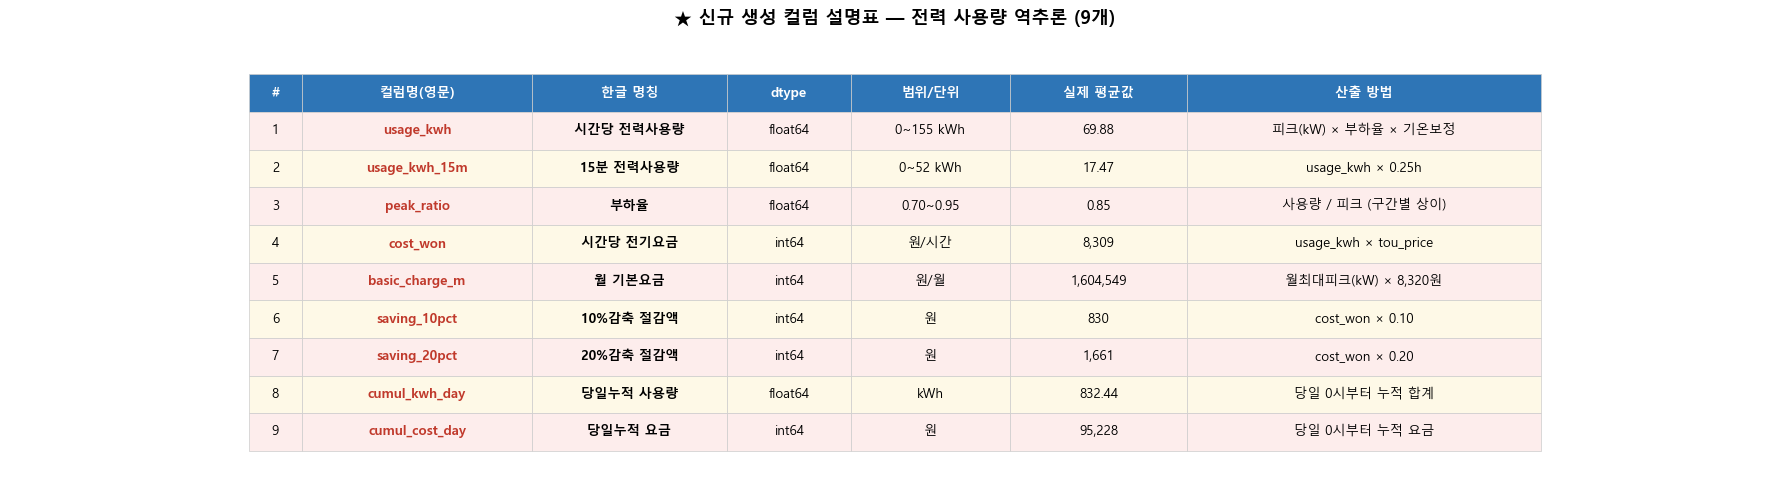

컬럼 설명표 완료


In [7]:
# ================================================
# 전력 사용량 신규 컬럼 설명표 시각화
# ================================================

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 컬럼 정보 정의 ────────────────────────────────
col_info = [
    ('usage_kwh',      '시간당 전력사용량',  'float64', '0~155 kWh',  '피크(kW) × 부하율 × 기온보정'),
    ('usage_kwh_15m',  '15분 전력사용량',   'float64', '0~52 kWh',   'usage_kwh × 0.25h'),
    ('peak_ratio',     '부하율',           'float64', '0.70~0.95',  '사용량 / 피크 (구간별 상이)'),
    ('cost_won',       '시간당 전기요금',    'int64',   '원/시간',     'usage_kwh × tou_price'),
    ('basic_charge_m', '월 기본요금',       'int64',   '원/월',       '월최대피크(kW) × 8,320원'),
    ('saving_10pct',   '10%감축 절감액',    'int64',   '원',          'cost_won × 0.10'),
    ('saving_20pct',   '20%감축 절감액',    'int64',   '원',          'cost_won × 0.20'),
    ('cumul_kwh_day',  '당일누적 사용량',    'float64', 'kWh',        '당일 0시부터 누적 합계'),
    ('cumul_cost_day', '당일누적 요금',      'int64',   '원',          '당일 0시부터 누적 요금'),
]

# ── 실제 데이터 통계 추가 ─────────────────────────
stats = {}
new_cols = [r[0] for r in col_info]
for col in new_cols:
    if col in df_power.columns:
        stats[col] = {
            'mean': df_power[col].mean(),
            'max' : df_power[col].max(),
        }

# ── 표 데이터 구성 ────────────────────────────────
headers = ['#', '컬럼명(영문)', '한글 명칭', 'dtype', '범위/단위', '실제 평균값', '산출 방법']
rows = []
for i, (col, kor, dtype, rng, method) in enumerate(col_info, 1):
    mean_val = stats.get(col, {}).get('mean', 0)
    if dtype == 'float64':
        mean_str = f"{mean_val:.2f}"
    else:
        mean_str = f"{int(mean_val):,}"
    rows.append([str(i), col, kor, dtype, rng, mean_str, method])

# ── 시각화 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
ax.axis('off')

col_widths = [0.03, 0.13, 0.11, 0.07, 0.09, 0.10, 0.20]

table = ax.table(
    cellText=rows,
    colLabels=headers,
    cellLoc='center',
    loc='center',
    colWidths=col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2.0)

# 헤더 스타일
for j in range(len(headers)):
    table[0, j].set_facecolor('#2E75B6')
    table[0, j].set_text_props(color='white', fontweight='bold')

# 행 스타일
row_colors = ['#FDEDEC', '#FEF9E7']
for i in range(1, len(rows)+1):
    for j in range(len(headers)):
        table[i, j].set_facecolor(row_colors[(i-1) % 2])
        # 컬럼명(영문) 빨강 강조
        if j == 1:
            table[i, j].set_text_props(color='#C0392B', fontweight='bold')
        # 한글 명칭 진하게
        if j == 2:
            table[i, j].set_text_props(fontweight='bold')

# 테두리
for key, cell in table.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    cell.set_linewidth(0.5)

plt.title('★ 신규 생성 컬럼 설명표 — 전력 사용량 역추론 (9개)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("컬럼 설명표 완료")